# Clean Advanced Contextual Bandit Evaluation with Binary and Ordinal Rewards

This notebook evaluates Linear Thompson Sampling and LassoLinUCB on the serious V2 feature sets. It now compares LinearTS with both the fast diagonal posterior approximation and the full covariance posterior sampler. Exact bucket accuracy remains the main leaderboard metric, while the binary/ordinal rewards decide what signal the online model receives during updates.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start=None):
    path = Path(start or Path.cwd()).resolve()
    for candidate in [path] + list(path.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists():
            return candidate
    raise FileNotFoundError('Could not find repository root.')


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.bandits.lasso_bandit import LassoLinUCB
from src.bandits.linear_thompson_sampling import LinearThompsonSampling
from src.evaluation.advanced_bandit_benchmark import (
    DEFAULT_LASSO_GRID,
    DEFAULT_TS_GRID,
    FINAL_ADVANCED_FEATURE_SETS,
    REWARD_SCHEMES_TO_COMPARE,
    classwise_advanced_metrics,
    combine_advanced_results,
    evaluate_advanced_grid_for_rewards,
    evaluate_lasso_grid,
    evaluate_linear_ts_grid,
    make_static_baselines_for_feature_sets,
    plot_advanced_leaderboard,
    save_advanced_benchmark,
    summarize_advanced_errors,
)
from src.evaluation.feature_set_benchmark import available_final_feature_sets, load_v2_assets

RESULTS_DIR = REPO_ROOT / 'results' / 'v2_advanced_bandits'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Repo root:', REPO_ROOT)
print('Results dir:', RESULTS_DIR)

Repo root: /Users/dhillo/Garage/codeComplete/full measure/warfarin
Results dir: /Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits


## 1. Load cleaned V2 assets and choose feature sets

In [2]:
df_v2, feature_sets, preprocess_output_dir = load_v2_assets(REPO_ROOT)
selected_feature_sets = available_final_feature_sets(feature_sets, FINAL_ADVANCED_FEATURE_SETS)

print('V2 modeling table:', df_v2.shape)
print('Selected feature sets:', selected_feature_sets)
print('Reward schemes:', REWARD_SCHEMES_TO_COMPARE)

V2 modeling table: (5528, 225)
Selected feature sets: ['v2_pharmacogenetic_augmented_regression_hw', 'v2_strict_regression_hw_full_dummies']
Reward schemes: ['binary', 'ordinal']


In [3]:
static_baselines = make_static_baselines_for_feature_sets(df_v2, selected_feature_sets)
static_baselines.to_csv(RESULTS_DIR / 'static_baselines_for_selected_feature_sets.csv', index=False)
static_baselines.sort_values(['feature_set', 'accuracy'], ascending=[True, False])

,feature_set,algorithm,accuracy,fraction_incorrect,mean_ordinal_reward,n_correct,n_total
2,v2_pharmacogenetic_augmented_regression_hw,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,0.689219,3820,5528
1,v2_pharmacogenetic_augmented_regression_hw,Clinical Formula (regression_hw),0.639110,0.360890,0.637301,3533,5528
0,v2_pharmacogenetic_augmented_regression_hw,Fixed Medium Dose,0.611795,0.388205,0.611795,3382,5528
5,v2_strict_regression_hw_full_dummies,Pharmacogenetic Formula (regression_hw),0.691027,0.308973,0.689219,3820,5528
4,v2_strict_regression_hw_full_dummies,Clinical Formula (regression_hw),0.639110,0.360890,0.637301,3533,5528
3,v2_strict_regression_hw_full_dummies,Fixed Medium Dose,0.611795,0.388205,0.611795,3382,5528


## 2. Hyperparameter grids

The LinearTS grid includes both covariance modes:

- `diagonal`: samples independent coefficient noise using only `diag(A_inv)`; fast and usually stable.
- `full`: samples correlated coefficient noise using the full covariance `A_inv`; slower, but better respects feature correlations.

The full-covariance scales are conservative because correlated exploration can be stronger than diagonal exploration.


In [4]:
print('LinearTS grid:')
for row in DEFAULT_TS_GRID:
    print(row)

print('LassoLinUCB grid:')
for row in DEFAULT_LASSO_GRID:
    print(row)

LinearTS grid:
{'lambda_reg': 5.0, 'sample_scale': 0.01, 'covariance_type': 'diagonal'}
{'lambda_reg': 10.0, 'sample_scale': 0.01, 'covariance_type': 'diagonal'}
{'lambda_reg': 10.0, 'sample_scale': 0.025, 'covariance_type': 'diagonal'}
{'lambda_reg': 20.0, 'sample_scale': 0.025, 'covariance_type': 'diagonal'}
{'lambda_reg': 10.0, 'sample_scale': 0.005, 'covariance_type': 'full'}
{'lambda_reg': 10.0, 'sample_scale': 0.01, 'covariance_type': 'full'}
{'lambda_reg': 10.0, 'sample_scale': 0.025, 'covariance_type': 'full'}
{'lambda_reg': 20.0, 'sample_scale': 0.01, 'covariance_type': 'full'}
{'lambda_reg': 20.0, 'sample_scale': 0.025, 'covariance_type': 'full'}
LassoLinUCB grid:
{'lasso_alpha': 0.0005, 'ucb_alpha': 0.0, 'lambda_reg': 10.0, 'min_samples_per_arm': 15, 'refit_frequency': 50}
{'lasso_alpha': 0.001, 'ucb_alpha': 0.0, 'lambda_reg': 10.0, 'min_samples_per_arm': 15, 'refit_frequency': 50}
{'lasso_alpha': 0.0025, 'ucb_alpha': 0.0, 'lambda_reg': 10.0, 'min_samples_per_arm': 20, 'refi

## 3. Linear Thompson Sampling: diagonal vs full covariance

This section runs LinearTS under both reward schemes and both covariance modes. The `covariance_type` column in the summary tells us whether diagonal or full covariance sampling is winning.


In [5]:
SEEDS = range(3)

ts_summary, ts_results, ts_scale_stats = evaluate_advanced_grid_for_rewards(
    evaluator=evaluate_linear_ts_grid,
    df=df_v2,
    feature_sets=feature_sets,
    bandit_cls=LinearThompsonSampling,
    feature_set_names=selected_feature_sets,
    param_grid=DEFAULT_TS_GRID,
    reward_schemes=REWARD_SCHEMES_TO_COMPARE,
    seeds=SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

ts_summary.head(15)

LinearTS feature set: v2_pharmacogenetic_augmented_regression_hw (217 features), reward=binary
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.025, cov=diagonal)
  LinearTS(lambda=20, scale=0.025, cov=diagonal)
  LinearTS(lambda=10, scale=0.005, cov=full)
  LinearTS(lambda=10, scale=0.01, cov=full)
  LinearTS(lambda=10, scale=0.025, cov=full)
  LinearTS(lambda=20, scale=0.01, cov=full)
  LinearTS(lambda=20, scale=0.025, cov=full)
LinearTS feature set: v2_strict_regression_hw_full_dummies (213 features), reward=binary
  LinearTS(lambda=5, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.01, cov=diagonal)
  LinearTS(lambda=10, scale=0.025, cov=diagonal)
  LinearTS(lambda=20, scale=0.025, cov=diagonal)
  LinearTS(lambda=10, scale=0.005, cov=full)
  LinearTS(lambda=10, scale=0.01, cov=full)
  LinearTS(lambda=10, scale=0.025, cov=full)
  LinearTS(lambda=20, scale=0.01, cov=full)
  LinearTS(lambda=20, scale=0

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,final_fraction_incorrect_ci95,late_accuracy_ci95,late_mean_reward_ci95,feature_set,algorithm_family,config_name,n_features,lambda_reg,sample_scale,covariance_type
18,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,3,0.677460,0.000479,0.675651,0.000313,1793.000000,1.732051,0.322540,...,0.000542,0.038960,0.039547,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",217,5.0,0.010,diagonal
19,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",ordinal,3,0.677038,0.001785,0.675410,0.001473,1794.333333,8.144528,0.322962,...,0.002020,0.046767,0.047420,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",217,10.0,0.025,diagonal
0,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",binary,3,0.676978,0.001382,0.676978,0.001382,1785.666667,7.637626,0.323022,...,0.001563,0.038960,0.038960,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",217,10.0,0.010,diagonal
1,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",binary,3,0.676556,0.003658,0.676556,0.003658,1788.000000,20.223748,0.323444,...,0.004140,0.038828,0.038828,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",217,10.0,0.025,diagonal
20,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,3,0.675772,0.003396,0.674385,0.003451,1800.000000,19.078784,0.324228,...,0.003842,0.039352,0.038960,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",217,10.0,0.010,diagonal
2,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",binary,3,0.674747,0.003531,0.674747,0.003531,1798.000000,19.519221,0.325253,...,0.003996,0.038073,0.038073,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",217,5.0,0.010,diagonal
21,"LinearTS(lambda=10, scale=0.025, cov=full)",ordinal,3,0.674385,0.004745,0.672757,0.004796,1809.000000,26.514147,0.325615,...,0.005369,0.029101,0.030811,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=full)",217,10.0,0.025,full
22,"LinearTS(lambda=10, scale=0.005, cov=full)",ordinal,3,0.674264,0.003835,0.672395,0.004145,1811.000000,22.912878,0.325736,...,0.004339,0.028895,0.029682,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.005, cov=full)",217,10.0,0.005,full
23,"LinearTS(lambda=10, scale=0.01, cov=full)",ordinal,3,0.673601,0.003574,0.672033,0.003613,1813.000000,19.974984,0.326399,...,0.004044,0.025236,0.027001,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=full)",217,10.0,0.010,full
3,"LinearTS(lambda=10, scale=0.025, cov=full)",binary,3,0.673420,0.010132,0.673420,0.010132,1805.333333,56.011903,0.326580,...,0.011466,0.034174,0.034174,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=full)",217,10.0,0.025,full


### LinearTS covariance checkpoint

Use this table to check whether full covariance sampling is improving over the diagonal approximation before comparing against LassoLinUCB.


In [6]:
ts_covariance_checkpoint = (
    ts_summary
    .groupby(['covariance_type', 'reward_scheme'], dropna=False)
    .agg(
        best_accuracy=('final_accuracy_mean', 'max'),
        mean_top3_accuracy=('final_accuracy_mean', lambda s: s.sort_values(ascending=False).head(3).mean()),
        best_late_accuracy=('late_accuracy_mean', 'max'),
    )
    .reset_index()
    .sort_values('best_accuracy', ascending=False)
)

ts_covariance_checkpoint


,covariance_type,reward_scheme,best_accuracy,mean_top3_accuracy,best_late_accuracy
1,diagonal,ordinal,0.677460,0.676757,0.695333
0,diagonal,binary,0.676978,0.676093,0.695333
3,full,ordinal,0.674385,0.674083,0.690667
2,full,binary,0.673420,0.670526,0.692667


## 4. LassoLinUCB under both reward schemes

In [7]:
lasso_summary, lasso_results, lasso_scale_stats = evaluate_advanced_grid_for_rewards(
    evaluator=evaluate_lasso_grid,
    df=df_v2,
    feature_sets=feature_sets,
    bandit_cls=LassoLinUCB,
    feature_set_names=selected_feature_sets,
    param_grid=DEFAULT_LASSO_GRID,
    reward_schemes=REWARD_SCHEMES_TO_COMPARE,
    seeds=SEEDS,
    standardize=True,
    progress=False,
    verbose=True,
)

lasso_summary.head(15)

LassoLinUCB feature set: v2_pharmacogenetic_augmented_regression_hw (217 features), reward=binary
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)
LassoLinUCB feature set: v2_strict_regression_hw_full_dummies (213 features), reward=binary
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, warmup=20, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0.025, lambda=10, warmup=20, refit=50)
LassoLinUCB feature set: v2_pharmacogenetic_augmented_regression_hw (217 features), reward=ordinal
  LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lasso=0.001, alpha=0, lambda=10, warmup=15, refit=50)
  LassoLinUCB(lass

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,late_mean_reward_ci95,feature_set,algorithm_family,config_name,n_features,lambda_reg,lasso_alpha,ucb_alpha,min_samples_per_arm,refit_frequency
0,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",binary,3,0.668174,0.004708,0.668174,0.004708,1834.333333,26.025628,0.331826,...,0.022969,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",217,10.0,0.0025,0.000,20,50
1,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",binary,3,0.667451,0.004244,0.667451,0.004244,1838.333333,23.459184,0.332549,...,0.024930,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",217,10.0,0.0010,0.025,20,50
8,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",ordinal,3,0.667390,0.002409,0.663350,0.001782,1861.000000,9.848858,0.332610,...,0.024200,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",217,10.0,0.0025,0.000,20,50
9,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",ordinal,3,0.666003,0.002902,0.660878,0.003624,1874.666667,20.033306,0.333997,...,0.034049,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",217,10.0,0.0010,0.025,20,50
10,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",ordinal,3,0.665581,0.005130,0.660275,0.004215,1878.000000,23.302360,0.334419,...,0.033134,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",217,10.0,0.0010,0.000,15,50
11,"LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, ...",ordinal,3,0.664737,0.002456,0.658225,0.002361,1889.333333,13.051181,0.335263,...,0.038563,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, ...",217,10.0,0.0005,0.000,15,50
2,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",binary,3,0.663953,0.002721,0.663953,0.002721,1857.666667,15.044379,0.336047,...,0.028895,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0, lambda=10, w...",217,10.0,0.0010,0.000,15,50
3,"LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, ...",binary,3,0.663109,0.001060,0.663109,0.001060,1862.333333,5.859465,0.336891,...,0.038674,v2_pharmacogenetic_augmented_regression_hw,LassoLinUCB,"LassoLinUCB(lasso=0.0005, alpha=0, lambda=10, ...",217,10.0,0.0005,0.000,15,50
4,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",binary,3,0.663049,0.002233,0.663049,0.002233,1862.666667,12.342339,0.336951,...,0.021747,v2_strict_regression_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.0025, alpha=0, lambda=10, ...",213,10.0,0.0025,0.000,20,50
12,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",ordinal,3,0.659793,0.001812,0.653763,0.001447,1914.000000,8.000000,0.340207,...,0.038497,v2_strict_regression_hw_full_dummies,LassoLinUCB,"LassoLinUCB(lasso=0.001, alpha=0.025, lambda=1...",213,10.0,0.0010,0.025,20,50


## 5. Combined advanced leaderboard

In [8]:
advanced_summary = pd.concat([ts_summary, lasso_summary], ignore_index=True).sort_values(
    'final_accuracy_mean', ascending=False
)
advanced_results = combine_advanced_results(ts_results, lasso_results)
advanced_scale_stats = pd.concat([ts_scale_stats, lasso_scale_stats], ignore_index=True)

advanced_summary.head(25)

,algorithm,reward_scheme,n_runs,final_accuracy_mean,final_accuracy_std,final_reward_mean,final_reward_std,final_regret_mean,final_regret_std,final_fraction_incorrect_mean,...,algorithm_family,config_name,n_features,lambda_reg,sample_scale,covariance_type,lasso_alpha,ucb_alpha,min_samples_per_arm,refit_frequency
0,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,3,0.677460,0.000479,0.675651,0.000313,1793.000000,1.732051,0.322540,...,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",217,5.0,0.010,diagonal,NaN,NaN,NaN,NaN
1,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",ordinal,3,0.677038,0.001785,0.675410,0.001473,1794.333333,8.144528,0.322962,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",217,10.0,0.025,diagonal,NaN,NaN,NaN,NaN
2,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",binary,3,0.676978,0.001382,0.676978,0.001382,1785.666667,7.637626,0.323022,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",217,10.0,0.010,diagonal,NaN,NaN,NaN,NaN
3,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",binary,3,0.676556,0.003658,0.676556,0.003658,1788.000000,20.223748,0.323444,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",217,10.0,0.025,diagonal,NaN,NaN,NaN,NaN
4,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,3,0.675772,0.003396,0.674385,0.003451,1800.000000,19.078784,0.324228,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",217,10.0,0.010,diagonal,NaN,NaN,NaN,NaN
5,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",binary,3,0.674747,0.003531,0.674747,0.003531,1798.000000,19.519221,0.325253,...,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",217,5.0,0.010,diagonal,NaN,NaN,NaN,NaN
6,"LinearTS(lambda=10, scale=0.025, cov=full)",ordinal,3,0.674385,0.004745,0.672757,0.004796,1809.000000,26.514147,0.325615,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=full)",217,10.0,0.025,full,NaN,NaN,NaN,NaN
7,"LinearTS(lambda=10, scale=0.005, cov=full)",ordinal,3,0.674264,0.003835,0.672395,0.004145,1811.000000,22.912878,0.325736,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.005, cov=full)",217,10.0,0.005,full,NaN,NaN,NaN,NaN
8,"LinearTS(lambda=10, scale=0.01, cov=full)",ordinal,3,0.673601,0.003574,0.672033,0.003613,1813.000000,19.974984,0.326399,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=full)",217,10.0,0.010,full,NaN,NaN,NaN,NaN
9,"LinearTS(lambda=10, scale=0.025, cov=full)",binary,3,0.673420,0.010132,0.673420,0.010132,1805.333333,56.011903,0.326580,...,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=full)",217,10.0,0.025,full,NaN,NaN,NaN,NaN


In [9]:
written = save_advanced_benchmark(
    RESULTS_DIR,
    prefix='advanced_bandit',
    summary=advanced_summary,
    results=advanced_results,
    scale_stats=advanced_scale_stats,
)
written

{'advanced_bandit_summary': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_summary.csv',
 'advanced_bandit_results': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_results.csv',
 'advanced_bandit_error_summary': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_error_summary.csv',
 'advanced_bandit_classwise': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_classwise.csv',
 'advanced_bandit_confusion_true_normalized': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_confusion_true_normalized.csv',
 'advanced_bandit_confusion_counts': '/Users/dhillo/Garage/codeComplete/full measure/warfarin/results/v2_advanced_bandits/advanced_bandit_confusion_counts.csv',
 'advanced_bandit_scale_stats': '/Users/dhillo/Garage/codeComplete/full 

## 6. Diagnostics for the best advanced configuration

In [10]:
advanced_error_summary = summarize_advanced_errors(advanced_results)
advanced_error_summary.sort_values('accuracy_mean', ascending=False).head(20)

,feature_set,algorithm_family,algorithm,config_name,reward_scheme,lambda_reg,sample_scale,covariance_type,lasso_alpha,ucb_alpha,...,mean_regret_mean,mean_regret_std,severe_error_rate_mean,severe_error_rate_std,one_step_error_rate_mean,underdose_rate_mean,overdose_rate_mean,accuracy_ci95,mean_reward_ci95,severe_error_rate_ci95
25,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)","LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,5.0,0.010,diagonal,NaN,NaN,...,0.324349,0.000313,0.001809,0.000479,0.320731,0.167089,0.155451,0.000542,0.000355,0.000542
15,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)","LinearTS(lambda=10, scale=0.025, cov=diagonal)",ordinal,10.0,0.025,diagonal,NaN,NaN,...,0.324590,0.001473,0.001628,0.000313,0.321334,0.167089,0.155873,0.002020,0.001667,0.000355
10,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)","LinearTS(lambda=10, scale=0.01, cov=diagonal)",binary,10.0,0.010,diagonal,NaN,NaN,...,0.323022,0.001382,0.001447,0.000181,0.321575,0.169380,0.153642,0.001563,0.001563,0.000205
14,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=diagonal)","LinearTS(lambda=10, scale=0.025, cov=diagonal)",binary,10.0,0.025,diagonal,NaN,NaN,...,0.323444,0.003658,0.002171,0.000724,0.321274,0.168657,0.154788,0.004140,0.004140,0.000819
11,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=diagonal)","LinearTS(lambda=10, scale=0.01, cov=diagonal)",ordinal,10.0,0.010,diagonal,NaN,NaN,...,0.325615,0.003451,0.001387,0.000276,0.322841,0.166305,0.157923,0.003842,0.003906,0.000313
24,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)","LinearTS(lambda=5, scale=0.01, cov=diagonal)",binary,5.0,0.010,diagonal,NaN,NaN,...,0.325253,0.003531,0.002894,0.000789,0.322359,0.164918,0.160335,0.003996,0.003996,0.000892
17,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=full)","LinearTS(lambda=10, scale=0.025, cov=full)",ordinal,10.0,0.025,full,NaN,NaN,...,0.327243,0.004796,0.001628,0.000313,0.323987,0.165702,0.159913,0.005369,0.005428,0.000355
9,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.005, cov=full)","LinearTS(lambda=10, scale=0.005, cov=full)",ordinal,10.0,0.005,full,NaN,NaN,...,0.327605,0.004145,0.001869,0.000377,0.323866,0.167692,0.158044,0.004339,0.004690,0.000426
13,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.01, cov=full)","LinearTS(lambda=10, scale=0.01, cov=full)",ordinal,10.0,0.010,full,NaN,NaN,...,0.327967,0.003613,0.001568,0.000209,0.324831,0.166425,0.159973,0.004044,0.004089,0.000236
16,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=10, scale=0.025, cov=full)","LinearTS(lambda=10, scale=0.025, cov=full)",binary,10.0,0.025,full,NaN,NaN,...,0.326580,0.010132,0.001930,0.000104,0.324650,0.163712,0.162868,0.011466,0.011466,0.000118


In [11]:
advanced_classwise = classwise_advanced_metrics(advanced_results)
best = advanced_summary.iloc[0]
best_filter = (
    (advanced_classwise['feature_set'] == best['feature_set'])
    & (advanced_classwise['algorithm_family'] == best['algorithm_family'])
    & (advanced_classwise['config_name'] == best['config_name'])
    & (advanced_classwise['reward_scheme'] == best['reward_scheme'])
)
advanced_classwise.loc[best_filter].sort_values('class_id')

,feature_set,algorithm_family,algorithm,config_name,reward_scheme,lambda_reg,sample_scale,covariance_type,lasso_alpha,ucb_alpha,...,n_runs,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,support_mean,recall_ci95,f1_ci95
75,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)","LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,5.0,0.01,diagonal,NaN,NaN,...,3,0.682890,0.008288,0.441472,0.024275,0.535876,0.015648,1495.0,0.027469,0.017708
76,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)","LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,5.0,0.01,diagonal,NaN,NaN,...,3,0.678560,0.001670,0.904002,0.003452,0.775218,0.000200,3382.0,0.003907,0.000226
77,v2_pharmacogenetic_augmented_regression_hw,Linear Thompson Sampling,"LinearTS(lambda=5, scale=0.01, cov=diagonal)","LinearTS(lambda=5, scale=0.01, cov=diagonal)",ordinal,5.0,0.01,diagonal,NaN,NaN,...,3,0.207792,0.284827,0.042499,0.072284,0.068916,0.116759,651.0,0.081797,0.132126


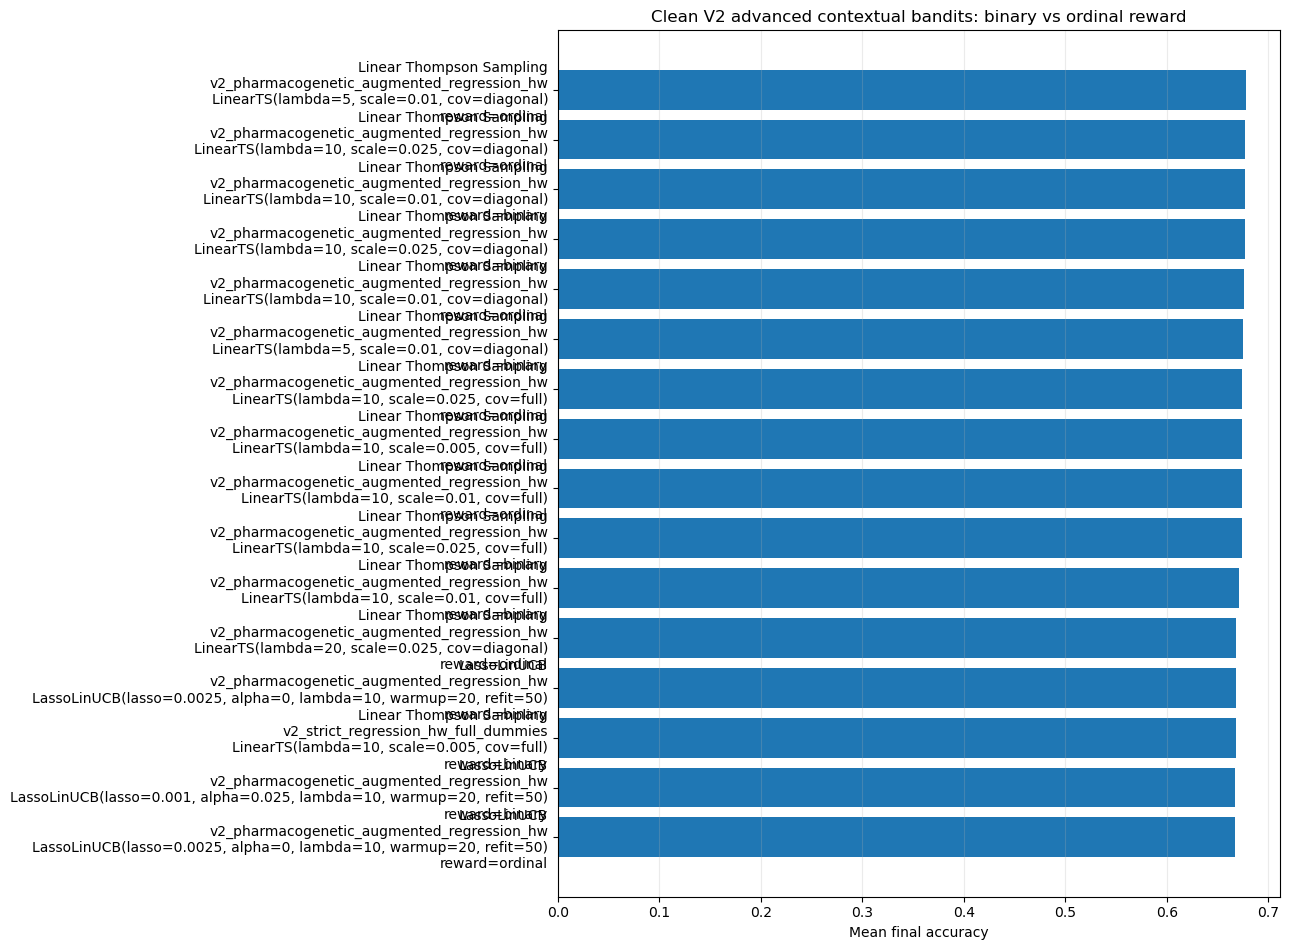

In [12]:
fig, ax = plot_advanced_leaderboard(
    advanced_summary,
    top_n=16,
    title='Clean V2 advanced contextual bandits: binary vs ordinal reward',
)
fig.savefig(RESULTS_DIR / 'advanced_bandit_reward_leaderboard.png', dpi=180, bbox_inches='tight')
plt.show()

## 7. Reward comparison checkpoint

The ordinal reward changes what the online model learns from mistakes, but the leaderboard still uses exact bucket accuracy. Check class-wise recall and severe-error rates before deciding whether ordinal reward is genuinely better.

In [13]:
comparison_cols = [
    'algorithm_family', 'reward_scheme', 'feature_set', 'config_name',
    'final_accuracy_mean', 'final_accuracy_ci95', 'final_reward_mean',
    'late_accuracy_mean', 'final_regret_mean',
]
advanced_summary[comparison_cols].sort_values('final_accuracy_mean', ascending=False).head(30)

,algorithm_family,reward_scheme,feature_set,config_name,final_accuracy_mean,final_accuracy_ci95,final_reward_mean,late_accuracy_mean,final_regret_mean
0,Linear Thompson Sampling,ordinal,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",0.677460,0.000542,0.675651,0.695333,1793.000000
1,Linear Thompson Sampling,ordinal,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",0.677038,0.002020,0.675410,0.694000,1794.333333
2,Linear Thompson Sampling,binary,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",0.676978,0.001563,0.676978,0.693333,1785.666667
3,Linear Thompson Sampling,binary,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.025, cov=diagonal)",0.676556,0.004140,0.676556,0.695333,1788.000000
4,Linear Thompson Sampling,ordinal,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.01, cov=diagonal)",0.675772,0.003842,0.674385,0.688667,1800.000000
5,Linear Thompson Sampling,binary,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=5, scale=0.01, cov=diagonal)",0.674747,0.003996,0.674747,0.694000,1798.000000
6,Linear Thompson Sampling,ordinal,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.025, cov=full)",0.674385,0.005369,0.672757,0.688667,1809.000000
7,Linear Thompson Sampling,ordinal,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.005, cov=full)",0.674264,0.004339,0.672395,0.690000,1811.000000
8,Linear Thompson Sampling,ordinal,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.01, cov=full)",0.673601,0.004044,0.672033,0.690667,1813.000000
9,Linear Thompson Sampling,binary,v2_pharmacogenetic_augmented_regression_hw,"LinearTS(lambda=10, scale=0.025, cov=full)",0.673420,0.011466,0.673420,0.688000,1805.333333
